## 1장 2강: 데이터 분석 기초

### 2. 탐색적 데이터 분석(EDA, Exploratory Data Analysis)과 결측치/이상치

### 4. 타이타닉(Titanic) 탑승객 데이터 분석
#### 4.1 데이터 로드 및 결측치, 이상치 처리

타이타닉(Titanic) 탑승객 데이터 로드 하기

- df.head() → 앞부분 데이터 몇 줄 보기 / 기본값이 5행
- df.tail() → 뒷부분 데이터 몇 줄 보기 / 기본값이 5행
- df.info() → 컬럼 / dtype / 결측치 구조 보기
- df.shape → 행·열 개수 보기
- df.columns → 컬럼 이름 보기

In [16]:
import pandas as pd   #pandas 세팅
import numpy as np    #numpy 세팅
import matplotlib.pyplot as plt # matplotlib 세팅
import seaborn as sns # seaborn 세팅 : Python 데이터 시각화 라이브러리 / 터미널엣서 uv add seaborn 으로 세팅

df = sns.load_dataset("titanic")

# df.iloc[:5]
# df[:5]
df.head() # 간략하게 5행만 보기


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [17]:
df.columns           # 컬럼 목록 확인/ 컬럼이 너무 많으므로

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

데이터 요약 및 통계 확인 하기

In [18]:
# 정보 - 결측치 확인하기
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


- 전체 데이터 개수는 891개이지만 age는 714개, embarked는 889개, deck은 203개만 값이 채워져 있어 결측치가 있는 것으로 파악됩니다.

In [19]:
# 이상치 확인하기
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- fare의 평균은 약 32.2달러이고 상위 25% 지점의 값이 31달러인데, 최댓값은 512달러에 달해 비정상적인 요금(이상치)이 존재한다는 것을 확인할 수 있습니다.

결측치 파악하기

- df.isnull().sum()은 각 컬럼에 결측치가 몇 개 있는지 세는 코드
- 모델링이나 분석 전에 어떤 컬럼에 빈 값이 얼마나 있는지 확인하려고
- 비어 있음   → True
- 값이 있음   → False

In [20]:
df.isnull().sum() # axis=0 기준에서 확인 가능
# 해석
## age → 결측치 177개
## embarked → 결측치 2개
## deck → 결측치 688개
## fare → 결측치 없음

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

숫자형 데이터(나이): 전체 탑승객의 '평균(mean)'으로 빈칸 채우기

In [21]:
mean_age = df['age'].mean()
print('평균나이:',mean_age)

평균나이: 29.69911764705882


In [22]:
df.loc[:, 'age'] = df['age'].fillna(mean_age)
df.isna().sum() # 위에서 처리한 평균값으로 결측치가 채워졌는지 확인!!!!

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

문자/범주형 데이터(탑승 항구): 가장 많이 탑승한 곳인 '최빈값(mode)'으로 빈칸 채우기

- 최빈값 = 가장 자주 나온 값. 평균보다 범주형 데이터 결측치 처리에 더 잘 맞는 경우가 많아.

In [23]:
mode_embarked = df['embark_town'].mode()[0]  # 가장 정박을 많이한 항구
mode_embarked 

'Southampton'

In [24]:
mode_embarked = df['embark_town'].mode()[0]

df['embark_town'] = df['embark_town'].fillna(mode_embarked)

df['embarked'] = df['embark_town'].map(lambda x: x[0].upper())



df.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

특정 컬럼(deck) 을 '기준'으로 좌우(열 방향) 데이터를 채우기

In [25]:
df['deck'] = df['deck'].ffill()
df['deck'] = df['deck'].bfill()

df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

너무 비싼 요금(이상치) 걸러내기

요금평균: 30.582164076576575
중앙값: 14.4542


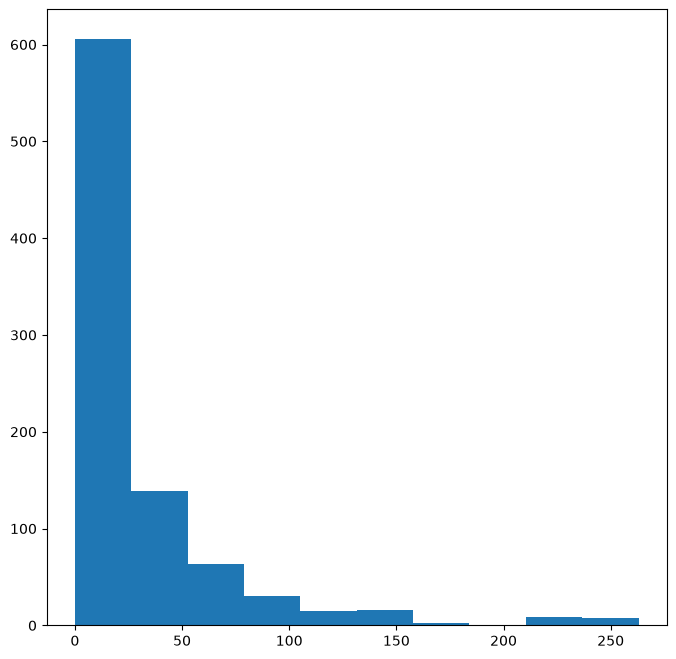

In [30]:
print("요금평균:",df['fare'].mean())
print("중앙값:",df['fare'].median())

plt.figure(figsize=(8,8))
plt.hist(df['fare'],bins=10)
plt.show()

In [27]:
df = df[df['fare'] < 300]

결측치/이상치 보완 결과 확인

In [28]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [29]:
df[df['fare']>300].count()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

#### 4.2 중복 데이터 처리하기
- 과적합은 모델이 학습 데이터에 너무 딱 맞춰져서, 처음 보는 데이터에서는 오히려 성능이 떨어지는 상태
- 과적합 = 원리를 배운 게 아니라 학습 데이터를 외운 상태

중복 데이터 확인하기

In [31]:
duplicate_count = df.duplicated().sum()
print(f"중복된 데이터 개수: {duplicate_count}개")

중복된 데이터 개수: 39개


중복 데이터 제거하기
- duplicate = 같은 데이터가 반복해서 들어간 것.

In [33]:
# 중복 데이터 확인
duplicated_rows = df[df.duplicated(keep=False)] # keep=False는 중복된 모든 행을 표시
duplicated_rows

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,C,Southampton,no,True
29,0,3,male,29.699118,0,0,7.8958,S,Third,man,True,C,Southampton,no,True
32,1,3,female,29.699118,0,0,7.7500,Q,Third,woman,False,B,Queenstown,yes,True
45,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,B,Southampton,no,True
47,1,3,female,29.699118,0,0,7.7500,Q,Third,woman,False,B,Queenstown,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,E,Southampton,no,True
844,0,3,male,17.000000,0,0,8.6625,S,Third,man,True,C,Southampton,no,True
846,0,3,male,29.699118,8,2,69.5500,S,Third,man,True,C,Southampton,no,False
859,0,3,male,29.699118,0,0,7.2292,C,Third,man,True,E,Cherbourg,no,True


In [34]:
# 완전히 일치하는 중복 행 제거 (첫 번째 데이터만 남기고 뒤에 나오는 중복은 삭제)
# df = df.drop_duplicates()

# 인덱스 정렬이 필요하다면 아래처럼 인덱스를 초기화해주는 것이 좋습니다.
df = df.drop_duplicates().reset_index(drop=True)


print(f"중복된 데이터 개수: {df.duplicated().sum()}개")

중복된 데이터 개수: 0개


#### 4.3 그래프로 시각화하기

내 컴퓨터에 맞는 한글 폰트 설정하기

In [38]:
# 내 컴퓨터에 맞는 한글 폰트 설정하기
import platform
import matplotlib.pyplot as plt

os_name = platform.system()
if os_name == "Windows":
    plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우
elif os_name == "Darwin":
    plt.rcParams['font.family'] = 'AppleGothic'   # 맥북
else:
    plt.rcParams['font.family'] = 'NanumGothic'   # 기타(코랩 등)

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

도화지(Figure)와 3개의 액자(Axes) 준비

C:\Users\jihyu\AppData\Local\Temp\ipykernel_28688\542471518.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='fare', data=df, ax=axes[1], palette='Set2')


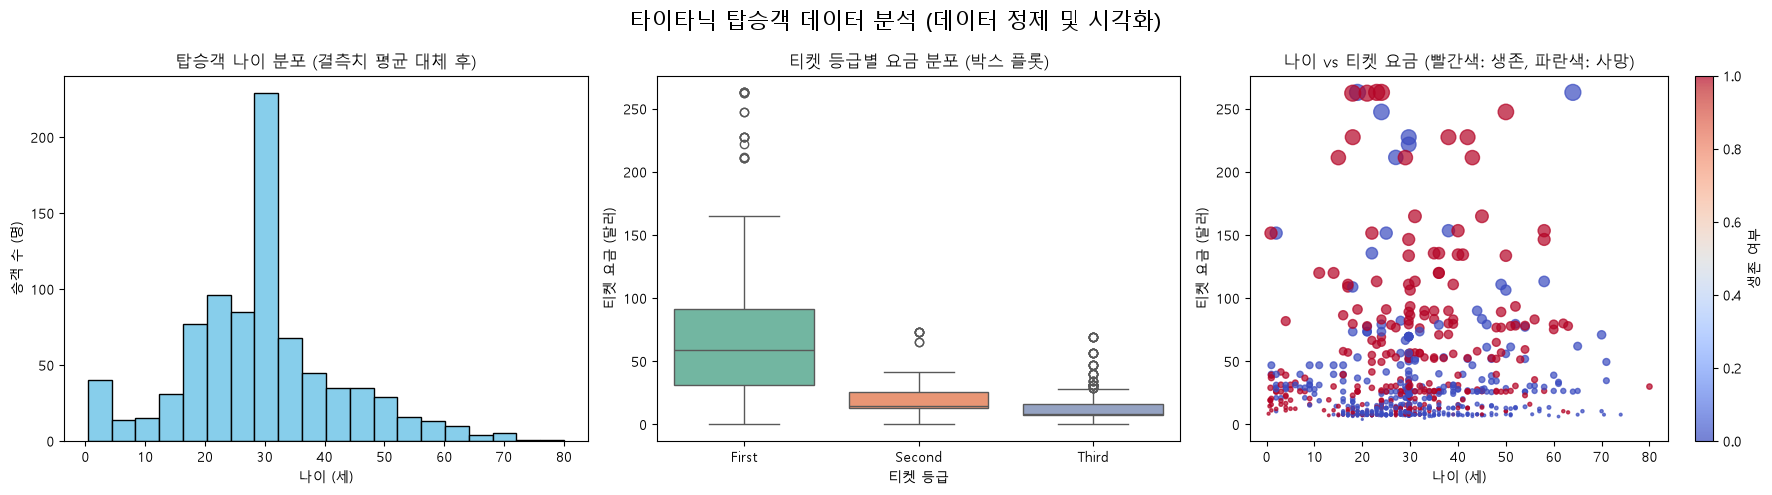

In [41]:
# 도화지(Figure)와 3개의 액자(Axes) 준비
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('타이타닉 탑승객 데이터 분석 (데이터 정제 및 시각화)', fontsize=16)

# [히스토그램] 탑승객 나이 분포
axes[0].hist(df['age'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('탑승객 나이 분포 (결측치 평균 대체 후)')
axes[0].set_xlabel('나이 (세)')
axes[0].set_ylabel('승객 수 (명)')

# [박스 플롯] 티켓 등급에 따른 요금 이상치 확인
# 박스(상자) 바깥쪽에 외롭게 찍혀 있는 점들이 바로 일반적인 범위를 벗어난 '이상치'들입니다.
sns.boxplot(x='class', y='fare', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('티켓 등급별 요금 분포 (박스 플롯)')
axes[1].set_xlabel('티켓 등급')
axes[1].set_ylabel('티켓 요금 (달러)')

# [산점도] 나이와 클리닝된 요금의 관계
scatter = axes[2].scatter(
    df['age'], 
    df['fare'], 
    c=df['survived'], # 생존 여부(1: 생존, 0: 사망)에 따라 색상이 다름
    cmap='coolwarm',
    s=df['fare'] / 2, # 요금이 비쌀수록 원이 조금 더 큼
    alpha=0.7
)
axes[2].set_title('나이 vs 티켓 요금 (빨간색: 생존, 파란색: 사망)')
axes[2].set_xlabel('나이 (세)')
axes[2].set_ylabel('티켓 요금 (달러)')

fig.colorbar(scatter, ax=axes[2], label='생존 여부')

plt.tight_layout()
plt.show()

그래프로 분석하기

**데이터 분석 결과**

*나이 분포 (결측치 평균 대체 후)*

<aside>
20대 후반에서 30대 초반 사이의 탑승객 수가 압도적으로 많습니다. 결측치를 평균값(약 30세 부근)으로 한 번에 대체하면서 해당 구간의 빈도(승객 수)가 비정상적으로 솟아오른 종 모양의 분포를 보입니다

</aside>

*티켓 등급별 요금 분포 (박스 플롯)*

<aside>
1등석(First)의 요금이 가장 높고 분포 범위가 넓으며, 등급이 낮아질수록 요금의 중앙값과 편차가 크게 줄어듭니다. 또한, 모든 등급(특히 1등석과 3등석)에서 일반적인 범위를 벗어난 고액의 이상치(Outlier)들이 다수 존재합니다.

</aside>

*나이 vs 티켓 요금 (산점도 및 생존 여부)*

<aside>
티켓 요금이 높을수록(그래프 상단) 빨간색 점(생존)의 비율이 눈에 띄게 높습니다. 반면 요금이 낮은 구간(그래프 하단)에는 파란색 점(사망)이 밀집되어 있어, "티켓 요금(또는 사회적 지위)이 높을수록 생존율이 높았다"는 명확한 상관관계를 보여줍니다.

</aside>